# 02 — Process Performance Map (most-likely-suffix, Helpdesk)

Experimental variant of `henryk/helpdesk/02_process_performance_map.ipynb`.

The henryk notebook runs the model deterministically (dropout off, no aleatoric noise) and picks the argmax next activity. Here we instead produce the **most-likely next activity under the probabilistic suffix predictor**:

1. Keep the trained MC-dropout rates (variational dropout in encoder, naive dropout in decoder).
2. For every prefix, batch `K` copies of the prefix into a single forward pass — because `_sample_mask` builds a fresh `[gates, B, ...]` mask per call, each batch slot gets an independent MC-dropout mask.
3. Sample first-step logits with aleatoric variance noise, take `argmax` per sample → K candidate next activities.
4. The **mode** over the K samples is the most-likely-next prediction. Compare to the actual next activity to build the per-transition PPM.

Colouring matches the henryk `ProcessPerformanceMap.get_color_for_accuracy` red→yellow→green gradient and layout (box nodes, Start circle, legend).

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
for p in [_current, _current / 'src']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import math
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.probabilistic_evaluation import ProbabilisticEvaluation

device = torch.device('cpu')

# Load with the trained dropout rates (dropout=None keeps the checkpoint's kwargs).
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=None)
model.eval()
model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = ProbabilisticEvaluation(
    model=model, dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat, all_num=CONFIG.all_num,
    samples_per_case=50, sample_argmax=True,
    use_variance_cat=True, use_variance_num=False,
)

# Activity vocab (idx -> name)
_cat_tuple = eval_helper.dataset.all_categories[0][eval_helper.concept_name_id]
activity_idx_to_name = {v: k for k, v in _cat_tuple[2].items()}

def _p(p_logit):
    if isinstance(p_logit, float):
        return p_logit
    return float(torch.sigmoid(p_logit))

print(f'Loaded model | |test|={len(test_dataset)} | cases={len(eval_helper.cases)}')
print(f'MC-dropout rates | encoder first={_p(model.encoder.first_layer.p_logit):.3f} | '
      f'decoder first={_p(model.decoder.first_layer.p_logit):.3f} | '
      f'outer model.dropout={model.dropout}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Loaded model | |test|=6077 | cases=916
MC-dropout rates | encoder first=0.100 | decoder first=0.100 | outer model.dropout=0.1


## Config

In [2]:
K = 50  # MC-dropout samples per prefix. 50 is a reasonable trade between stability and runtime.
USE_ALEATORIC = True  # add Gaussian noise to logits using _var head
print(f'MC samples per prefix: K={K}, aleatoric noise={USE_ALEATORIC}')

MC samples per prefix: K=50, aleatoric noise=True


## Collect per-prefix most-likely-next predictions

We only need the **first** decoder step (the next activity), so instead of running the full suffix K times we batch K copies of each prefix and run `model.inference(prefix=...)` once. Independent per-batch dropout masks give K independent MC samples.

In [3]:
activity_key = CONFIG.concept_name  # e.g. 'Activity' for Helpdesk
activity_mean_key = f'{activity_key}_mean'
activity_var_key = f'{activity_key}_var'


def _batch_tile(prefix, k):
    """Tile a (cats, nums) prefix to a batch of size k (copies of the same prefix)."""
    cats, nums = prefix
    # prefix tensors have shape [1, seq_len]; repeat along dim 0
    cats_b = [c.repeat(k, 1) for c in cats]
    nums_b = [n.repeat(k, 1) for n in nums]
    return cats_b, nums_b


def mc_most_likely_next(prefix, k, use_aleatoric):
    cats_b, nums_b = _batch_tile(prefix, k)
    prediction, _, _ = model.inference(prefix=(cats_b, nums_b))
    # prediction[0][0] = cat means (first step), prediction[1][0] = cat vars
    logits = prediction[0][0][activity_mean_key]  # [k, n_classes]
    if use_aleatoric:
        log_var = prediction[1][0][activity_var_key]
        noise = torch.normal(mean=torch.zeros_like(logits), std=torch.exp(log_var))
        logits = logits + noise
    preds = logits.argmax(dim=-1).cpu().numpy().tolist()
    return Counter(preds).most_common(1)[0][0], Counter(preds)


records = []
with torch.no_grad():
    for case_name, full_case in tqdm(eval_helper.cases.items(), total=len(eval_helper.cases)):
        for prefix_length, prefix, suffix in eval_helper._iterate_case(full_case):
            # actual next activity: first real index in suffix
            suffix_cats, _ = suffix
            actual_next_idx = suffix_cats[eval_helper.concept_name_id][0, 0].item()
            if actual_next_idx == 0:
                continue
            current_idx = prefix[0][eval_helper.concept_name_id][0, -1].item()
            if current_idx == 0:
                continue
            predicted_idx, votes = mc_most_likely_next(prefix, K, USE_ALEATORIC)
            records.append({
                'case_id': case_name,
                'prefix_length': prefix_length,
                'current_activity': activity_idx_to_name.get(current_idx, str(current_idx)),
                'actual_next_activity': activity_idx_to_name.get(actual_next_idx, str(actual_next_idx)),
                'predicted_next_activity': activity_idx_to_name.get(predicted_idx, str(predicted_idx)),
                'mode_votes': int(votes[predicted_idx]),
                'mode_fraction': float(votes[predicted_idx]) / K,
                'correct': predicted_idx == actual_next_idx,
            })
print(f'Collected {len(records)} prefix predictions')
print(f"Overall accuracy: {sum(r['correct'] for r in records) / len(records) * 100:.1f}%")
print(f"Average mode-fraction (agreement across K): {np.mean([r['mode_fraction'] for r in records]) * 100:.1f}%")

  0%|          | 0/916 [00:00<?, ?it/s]

Collected 3329 prefix predictions
Overall accuracy: 65.4%
Average mode-fraction (agreement across K): 87.9%


In [4]:
# --- Overall accuracy summary ---
from collections import defaultdict
import pandas as pd

n_total = len(records)
n_correct = sum(1 for r in records if r['correct'])
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    by_plen[r['prefix_length']]['total'] += 1
    by_plen[r['prefix_length']]['correct'] += int(r['correct'])
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

if n_total and 'mode_fraction' in records[0]:
    mean_conf = sum(r['mode_fraction'] for r in records) / n_total
    print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 2178/3329 = 0.6543 (65.43%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1      378    916  0.412664
             2      581    916  0.634279
             3      737    878  0.839408
             4      292    357  0.817927
             5      112    148  0.756757
             6       45     66  0.681818
             7       19     29  0.655172
             8        8     12  0.666667
             9        3      4  0.750000
            10        2      2  1.000000
            11        1      1  1.000000

Mean top-1 confidence: 87.92%


## Aggregate per-transition stats

In [5]:
from collections import defaultdict

stats = defaultdict(lambda: {'total': 0, 'correct': 0})
node_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for r in records:
    k = (r['current_activity'], r['actual_next_activity'])
    stats[k]['total'] += 1
    stats[k]['correct'] += int(r['correct'])
    node_stats[r['current_activity']]['total'] += 1
    node_stats[r['current_activity']]['correct'] += int(r['correct'])

rows = [{'source': s, 'target': t, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']} for (s, t), v in stats.items()]
transitions_df = pd.DataFrame(rows).sort_values(['source', 'total'], ascending=[True, False])
print(f'{len(transitions_df)} unique transitions')
transitions_df.head(20)

40 unique transitions


,source,target,correct,total,accuracy
0,Assign seriousness,Take in charge ticket,406,837,0.485066
5,Assign seriousness,Assign seriousness,0,96,0.000000
10,Assign seriousness,Resolve ticket,10,50,0.200000
15,Assign seriousness,Wait,0,11,0.000000
28,Assign seriousness,Require upgrade,0,1,0.000000
17,Closed,Closed,0,5,0.000000
23,Closed,Take in charge ticket,0,1,0.000000
25,Create SW anomaly,Resolve ticket,6,8,0.750000
27,Create SW anomaly,Require upgrade,0,2,0.000000
35,Create SW anomaly,Create SW anomaly,0,1,0.000000


## Process performance map

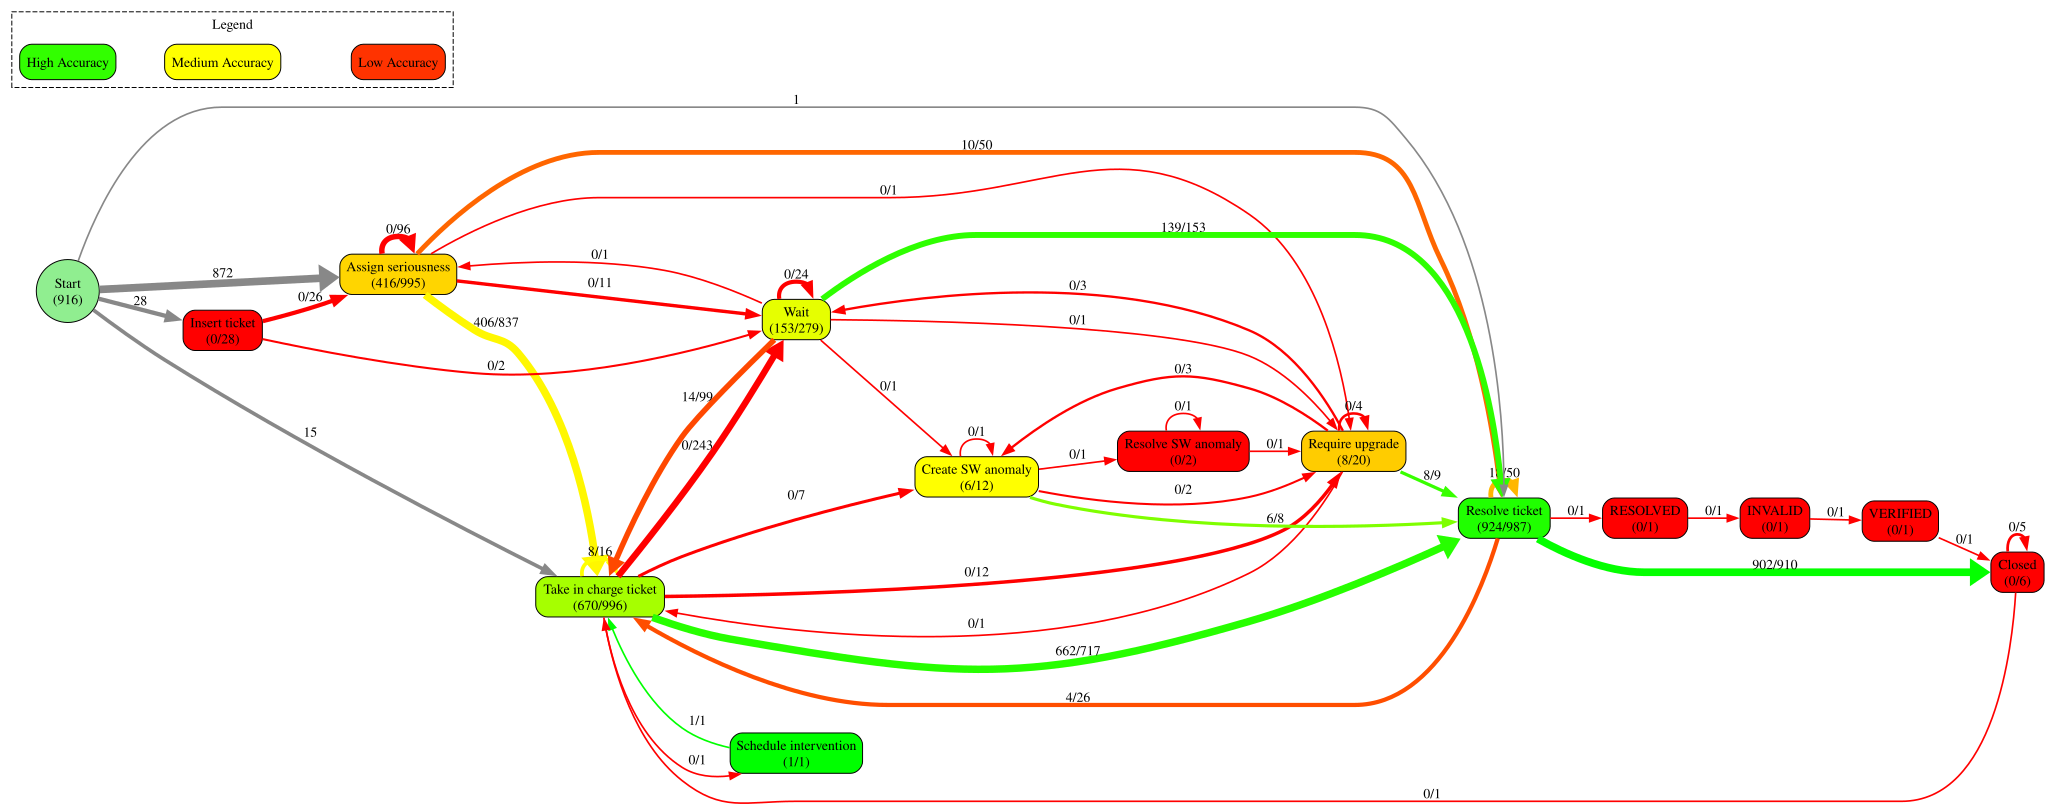

In [6]:
import graphviz

MIN_EDGE_COUNT = 0

def get_color_for_accuracy(accuracy: float) -> str:
    """Red (low) -> Yellow (mid) -> Green (high), identical to henryk ProcessPerformanceMap."""
    if accuracy < 0.5:
        r = 255
        g = int(255 * (accuracy * 2))
        b = 0
    else:
        r = int(255 * (1 - (accuracy - 0.5) * 2))
        g = 255
        b = 0
    return f'#{r:02x}{g:02x}{b:02x}'


dot = graphviz.Digraph(comment='Helpdesk PPM (most-likely-suffix)')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

for act, s in node_stats.items():
    if s['total'] > 0:
        acc = s['correct'] / s['total']
        label = f"{act}\n({s['correct']}/{s['total']})"
        fill = get_color_for_accuracy(acc)
    else:
        label = str(act); fill = 'white'
    dot.node(str(act), label=label, fillcolor=fill)

start_counts = {}
for r in records:
    if r['prefix_length'] == 1:
        start_counts[r['current_activity']] = start_counts.get(r['current_activity'], 0) + 1
total_cases = sum(start_counts.values())
if total_cases:
    dot.node('__START__', label=f'Start\n({total_cases})', shape='circle', fillcolor='#90EE90', style='filled')
    for act, cnt in start_counts.items():
        if cnt >= MIN_EDGE_COUNT:
            dot.edge('__START__', str(act), label=str(cnt), color='#888888',
                     penwidth=str(1 + math.log1p(cnt)))

for (src, tgt), s in stats.items():
    if s['total'] < MIN_EDGE_COUNT:
        continue
    acc = s['correct'] / s['total']
    color = get_color_for_accuracy(acc)
    dot.edge(str(src), str(tgt), label=f"{s['correct']}/{s['total']}", color=color,
             penwidth=str(1 + math.log1p(s['total'])))

with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High Accuracy', fillcolor=get_color_for_accuracy(0.9))
    legend.node('mid_acc', 'Medium Accuracy', fillcolor=get_color_for_accuracy(0.5))
    legend.node('low_acc', 'Low Accuracy', fillcolor=get_color_for_accuracy(0.1))
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')

dot

## Per-source summary & comparison hooks

In [7]:
print('Per-source-activity accuracy (most-likely-suffix decoder):')
for act, s in sorted(node_stats.items(), key=lambda x: -x[1]['total']):
    acc = s['correct'] / s['total']
    print(f"  {act:<30s} {s['correct']:5d}/{s['total']:<5d}  {acc * 100:5.1f}%")

Per-source-activity accuracy (most-likely-suffix decoder):
  Take in charge ticket            670/996     67.3%
  Assign seriousness               416/995     41.8%
  Resolve ticket                   924/987     93.6%
  Wait                             153/279     54.8%
  Insert ticket                      0/28       0.0%
  Require upgrade                    8/20      40.0%
  Create SW anomaly                  6/12      50.0%
  Closed                             0/6        0.0%
  Resolve SW anomaly                 0/2        0.0%
  Schedule intervention              1/1      100.0%
  RESOLVED                           0/1        0.0%
  INVALID                            0/1        0.0%
  VERIFIED                           0/1        0.0%
